# 03 - COVID-19 Univariate Analysis

This notebook performs univariate analysis on individual COVID-19 variables.

## Import Libraries

In [2]:
import os
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data loader module
from src.data_loader import load_csv
from src.visualization import set_style

# Set visualization style
set_style()

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Processed Data

Right now, we will only do this EDA on countries, because is where we have the main source of information

In [4]:
countries = pd.read_csv("data/processed/countries.csv", parse_dates=["date"])
countries.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39


In [5]:
numeric_cols = countries.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = countries.select_dtypes(include=["object", "category"]).columns.tolist()
date_cols = countries.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

## Univariate Analysis

In [6]:
countries.describe()

,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,new_deaths_smoothed,...,new_people_vaccinated_smoothed_per_hundred,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
count,287991,2.826290e+05,2.825990e+05,2.814500e+05,282629.000000,282599.000000,281450.000000,2.826290e+05,282607.000000,281464.000000,...,159462.000000,2.867380e+05,281883.000000,287991.000000,287991.000000,287991.000000,287991.000000,255190.000000,287991.000000,287991.000000
mean,2021-08-30 15:48:48.579017984,1.276399e+06,2.704670e+03,2.714478e+03,79458.602796,166.449334,167.087416,1.695408e+04,24.533770,24.626335,...,0.082422,3.400692e+07,437.962991,31.195932,73.453035,21748.714632,11.324572,9.053067,73.127703,2.714319
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,5.130000e+02,0.136470,14.298000,18.817699,708.178284,0.000000,1.100000,3.487560,0.300000
25%,2020-10-31 00:00:00,1.803000e+03,0.000000e+00,8.571429e-01,749.723900,0.000000,0.188989,1.500000e+01,0.000000,0.000000,...,0.002096,3.975420e+05,38.660870,22.243999,68.748703,5579.981445,0.654043,5.600000,58.306389,1.000000
50%,2021-08-31 00:00:00,3.059100e+04,4.000000e+00,2.928571e+01,12031.853000,0.468224,9.930929,3.420000e+02,0.000000,0.142857,...,0.017375,5.473195e+06,95.323570,31.683001,74.695999,14918.296875,2.436315,7.400000,87.331657,2.040000
75%,2022-06-30 00:00:00,3.601090e+05,2.470000e+02,4.605714e+02,93873.390000,46.231552,104.389580,5.382000e+03,3.000000,4.714286,...,0.084310,2.250904e+07,245.013458,39.080002,79.044800,34297.933594,10.221504,11.300000,97.261055,3.490000
max,2023-04-30 00:00:00,1.032664e+08,6.966046e+06,5.882128e+06,707442.940000,230762.550000,37463.746000,1.124063e+06,44047.000000,6829.714400,...,11.734285,1.425423e+09,21344.242188,59.875000,85.746399,117746.992188,85.317673,30.799999,100.000000,13.800000
std,NaN,5.930110e+06,4.189544e+04,3.772527e+04,134166.712949,1300.524832,666.871211,7.201102e+04,178.977474,138.131511,...,0.189295,1.364400e+08,1978.496403,9.714021,7.720065,21297.374933,18.507904,5.301044,28.281346,2.231152


Before analyzing the variables, we are going to divide them into mental groups:

* Total Size -> always right-skewed
    - population
    - total_cases
    - total_deaths

* Rates / Intensity -> comparable between countries
    - total_cases_per_million
    - deaths_per_million
    - icu_patients_per_million

* Sanitary System -> less skewed
    - hospital_beds_per_thousand
    - life_expectancy
    - handwashing_facilities
    - diabetes_prevalence

* Socioeconomic ones -> very skewed
    - gdp_per_capita
    - extreme_poverty


In [7]:
total_size_vars = ["total_cases", "total_deaths", "total_tests", "total_vaccinations"]
rate_vars = ["total_cases_per_million", "total_deaths_per_million", "icu_patients_per_million"]
sanitary_vars = ["hospital_beds_per_thousand", "life_expectancy", "handwashing_facilities", "diabetes_prevalence", "hosp_patients"]
socioeconomic_vars = ["gdp_per_capita", "extreme_poverty", "median_age"]

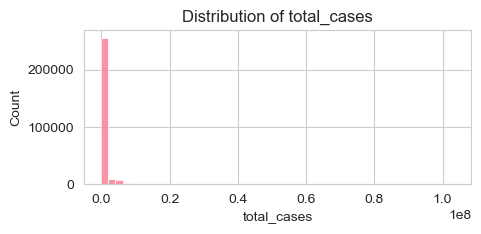

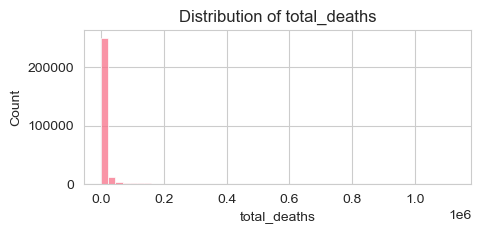

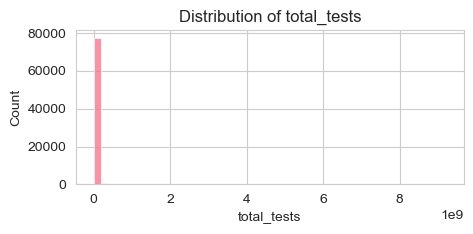

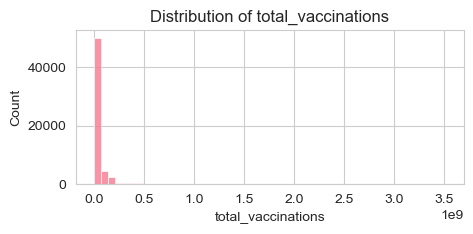

In [8]:
# total vars
for var in total_size_vars:
    plt.figure(figsize=(5, 2))
    sns.histplot(countries[var], bins=50)
    plt.title(f"Distribution of {var}")
    plt.show()

As we can see, all of this variables are right skewed, mining that there are some extreme cases. For example there may be days with a lot of total cases or total deaths (I supose that these are in the early days of the pandemic). However, the "normal" days were closer to 0.

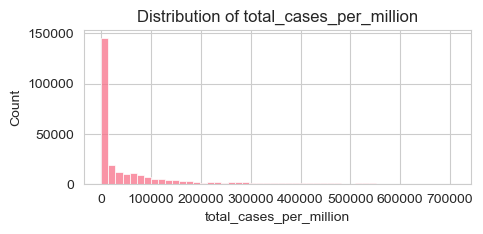

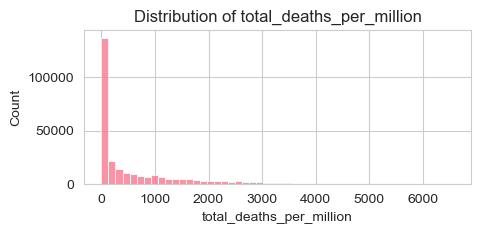

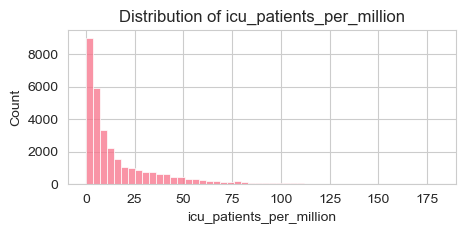

In [9]:
for var in rate_vars:
    plt.figure(figsize=(5, 2))
    sns.histplot(countries[var], bins=50)
    plt.title(f"Distribution of {var}")
    plt.show()

Here, we still see a right skewed distribution, but with less strength than before. This is due to the transformation of dividing by one million.

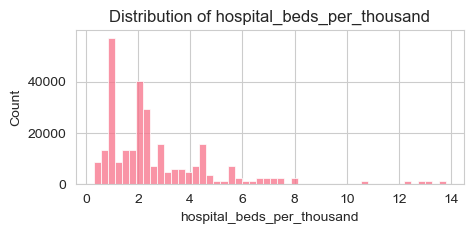

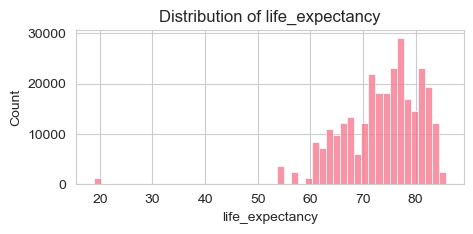

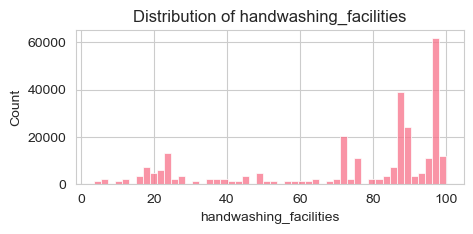

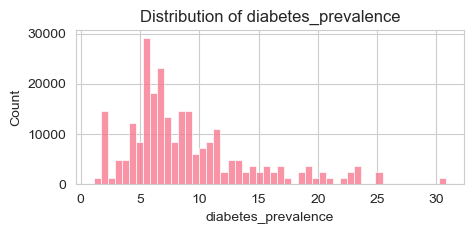

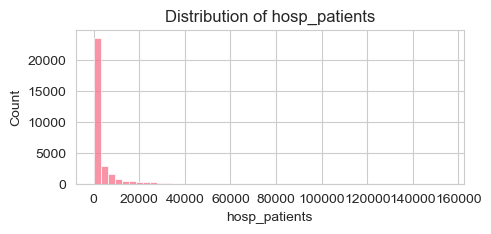

In [10]:
for var in sanitary_vars:
    plt.figure(figsize=(5, 2))
    sns.histplot(countries[var], bins=50)
    plt.title(f"Distribution of {var}")
    plt.show()

Here we start to see more normality in our data. We see that diabetes prevalence or distribution of life expectancy is more or less normal. We also see that there are a lot of countries with low handwashing facilities and some countries with more hospital beds per thousand than others. 

> It could be interesting to analyze if the countries where there are lower handwashing facilities are the countries with more deaths and if in the countries with more hospital beds were lower deaths.

We also see that patients in hospital are very right skewed meaning that there could have been a day/days with overbooking in the hospitals in the peak wave of the virus (We could analyze this correlation later).

Also it could be interesting to analyze if the countries with higher life expectancy had lower deaths than the others.

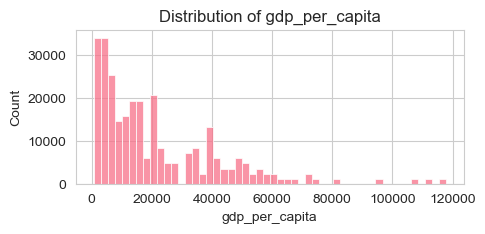

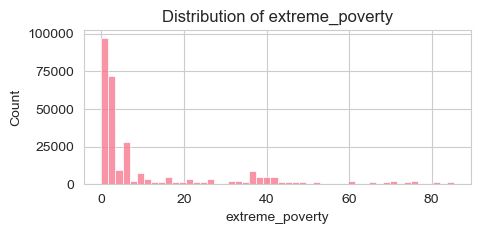

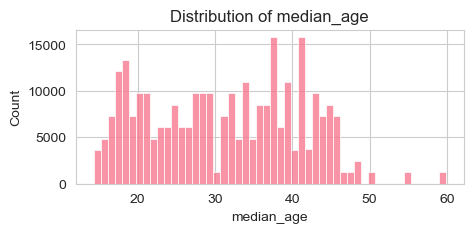

In [11]:
for var in socioeconomic_vars:
    plt.figure(figsize=(5, 2))
    sns.histplot(countries[var], bins=50)
    plt.title(f"Distribution of {var}")
    plt.show()

Here we can see that these socioeconomic variables are very right-skewed, meaning that there are countries with higher gdp and countries very poor.

However, there is a lot of variety in the median age distribution. It could also be interesting to analyze if the countries with more median age tended to report more deaths, because of the severity of the virus with older people.

### Categorical Variables

In [12]:
for col in [i for i in categorical_cols if i !="code"]:
    print(f"{col} value counts:")
    print(countries[col].value_counts(dropna=False))
    print("\n")

country value counts:
country
Afghanistan       1216
Nicaragua         1216
Moldova           1216
Monaco            1216
Mongolia          1216
                  ... 
Isle of Man       1213
Macao             1200
Cote d'Ivoire     1146
Transnistria        40
Western Sahara       1
Name: count, Length: 239, dtype: int64


continent value counts:
continent
Africa           69222
Europe           62035
Asia             60775
North America    49802
Oceania          29139
South America    17018
Name: count, dtype: int64




As we can see, there are a lot of countries with 1216 days and there are only 2 countries (Transinistria and Western Sahara) with less than 1000 days (40 and 1 days). We could exclude them from our analysis.

In relation with Continents, we can see that the countries with more registers are in Africa, Europe, Asia and North America. Oceania and South America are the ones with less records. This is due to the total countries in each continent.

### Date Variables

In [14]:
for col in date_cols:
    print(f"{col} min: {countries[col].min()}, max: {countries[col].max()}")

date min: 2020-01-01 00:00:00, max: 2023-04-30 00:00:00


It is more accurate analyze only in the time of the COVID and when oficially there was a global control of the virus. There is no need to analyze until today.